In [1]:
import numpy as np
import matplotlib.pyplot as plt
from eta_lattice import SpinConfiguration
from tqdm import tqdm

In [2]:
import numpy as np
from eta_lattice import SpinConfiguration

def get_neel_contribution(eta = 1., print = False):
    sc = SpinConfiguration(4, 4, 8, lowest_eignstates=5, delta=1., J2overJ1=1., lamb=0., eta=eta, print_data=False)
    min_e, gs_state = sc.get_ground_state()

    neel_state = np.array( [ [ (1 + (-1)**(x + y + 1))/2 for x in range(4) ] for y in range(4) ] ).reshape((4, 4))
    neel_basis = sc.map_config_to_basis(neel_state)
    if print:
        print(f'Neel state contribution to the ground state: {np.square(np.abs(gs_state[neel_basis]))}')
        print(f'Maximum contribution of single representative to the ground state: {np.square(np.max(np.abs(gs_state)))}')
    return np.square(np.abs(gs_state[neel_basis]))

points = []
etas = []
steps = 11

for ii in tqdm(range(steps)):
    eta = round(1. - ii/(steps - 1), 2)
    etas.append(eta)
    points.append(get_neel_contribution(eta))

100%|██████████| 11/11 [00:01<00:00,  6.93it/s]


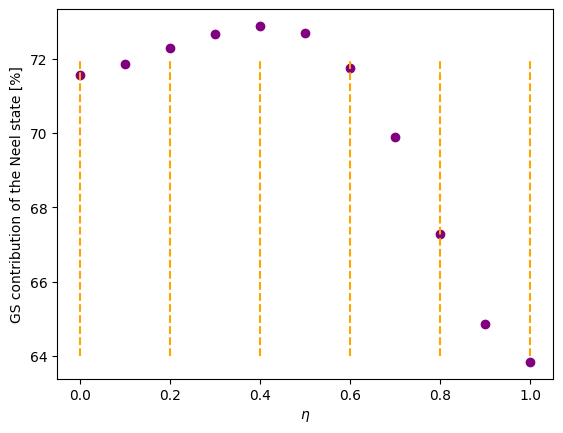

In [3]:
import matplotlib.pyplot as plt

plt.scatter(etas, np.array(points)*100, color = 'purple')
plt.xlabel(r'$\eta$')
plt.ylabel(r'GS contribution of the Neel state [%]')
plt.vlines( [0., .2, .4, .6, .8, 1.], 64, 72, 'orange', '--' )
plt.show()

In [4]:
from eta_phases_ad_hoc import Representation

k_s = np.arange(0., 20.1, 1.)

rand_int = int(np.floor(np.random.uniform(0, 101)))

phases = []

for k in tqdm(k_s):
    r = Representation(4, 4, 8, int(k))
    phases.append(np.abs(r.phases[rand_int]))

100%|██████████| 21/21 [00:21<00:00,  1.04s/it]


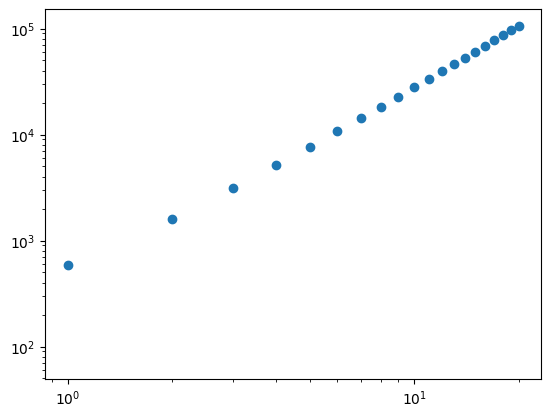

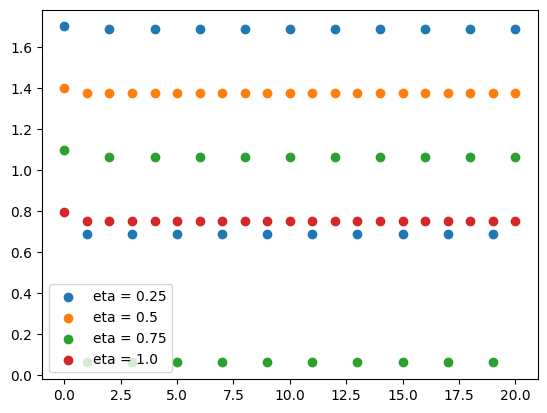

In [5]:
plt.scatter(k_s, phases)
plt.yscale('log')
plt.xscale('log')
plt.show()

e_s = np.arange(0.25, 1.1, .25)
for e in e_s:
    plt.scatter(k_s, np.mod(np.array(phases)*e, 2*np.pi)/np.pi, label = f'eta = {round(e, 2)}')
plt.legend()
plt.show()

k = 0.0


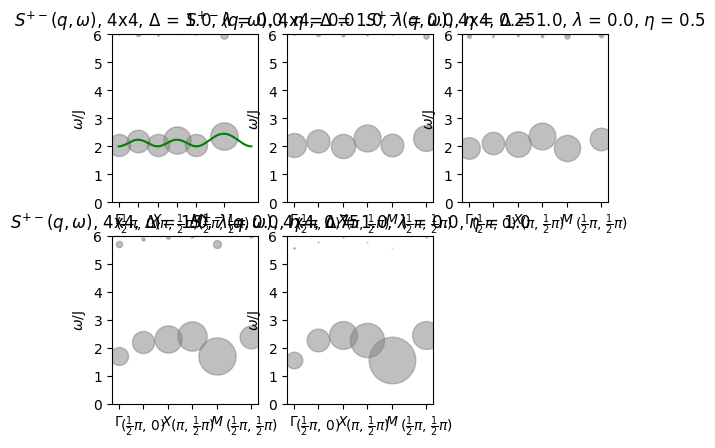

k = 1.0


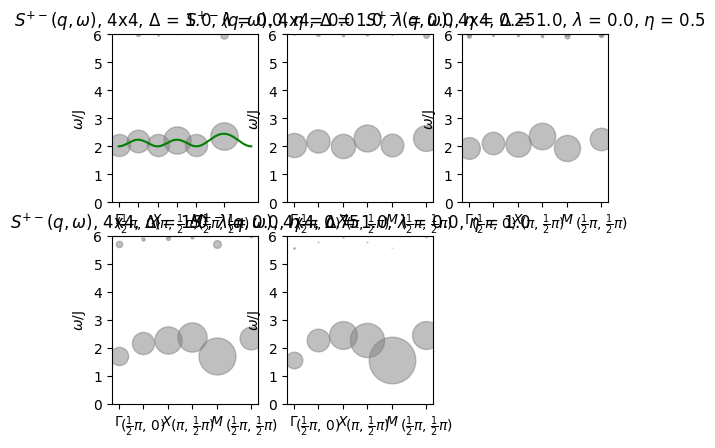

k = 2.0


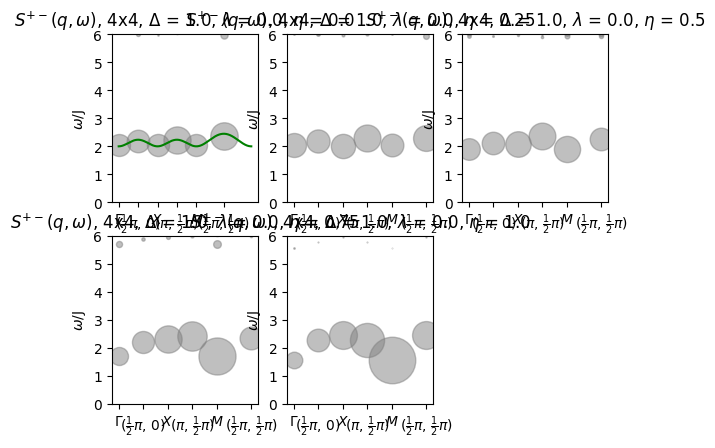

k = 3.0


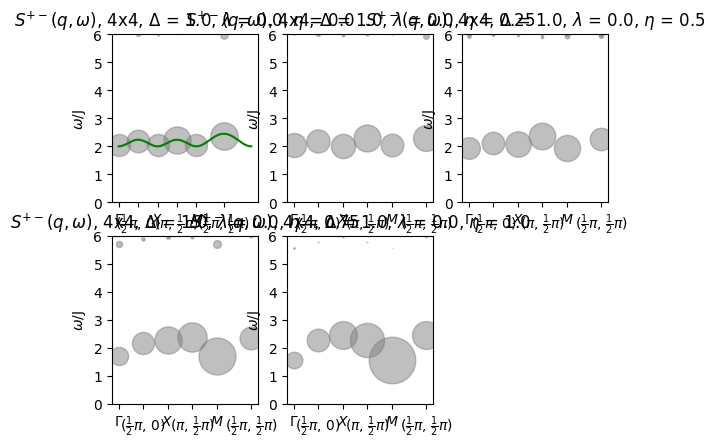

k = 4.0


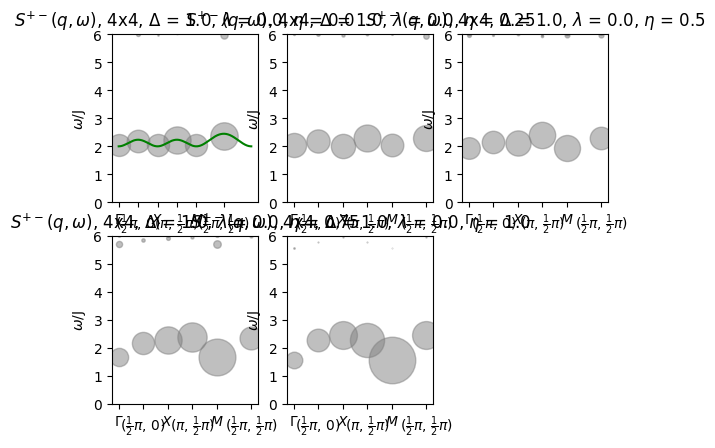

In [6]:
from eta_functions_mp2 import plot_SDSF

k_s = np.arange(0., 4.1, 1)

for k in k_s:
    r = Representation(4, 4, 8, int(k))
    r = Representation(4, 4, 7, int(k))

    scm = None
    variables = np.arange(0., 1.1, .25)

    print(f'k = {k}')
    for iv, var in enumerate(variables):
        plt.subplot(2, 3, iv + 1)
        plot_SDSF(scm, 4, 4, lamb=0., delta=1., eta=var, dir='+-', k_lowest=20, save=True, _print = False)
    plt.show()
